In [125]:
# import necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [88]:
# read the data
df = pd.read_csv('/Users/hamed/Documents/Papers/6.StressStrainData/TensileDataSet.csv')

print('data size before removing nan values:', df.shape[0])

# remove nan values
df = df.dropna()

print('data size after removing nan values:', df.shape[0])
print(df.head(2))

data size before removing nan values: 237
data size after removing nan values: 237
   No  Method  Grade  Bar size (mm)  Sleeve length (mm)  Outer diameter (mm)  \
0   1       0     60          32.26                 0.0                  0.0   
1   2       0     60          32.26                 0.0                  0.0   

   Temperature (c)  Yield stress (MPa)  Ultimate strength (MPa)  \
0               25          481.254059               814.270837   
1               25          495.733050               804.618177   

   Ultimate strain (%)  
0                 10.5  
1                  9.3  


In [96]:

##  Remove outliers based on the following criteria:
n_before = len(df)

df_clean = df[
    (df["Ultimate strain (%)"] <= 14)
    &
    (df["Ultimate strength (MPa)"] >= 200)
    &
    (df["Yield stress (MPa)"] <= 680)#680)
    &
    (df["Yield stress (MPa)"] >= 350)
].copy()

n_after = len(df_clean)

print(f"Rows before: {n_before}")
print(f"Rows after : {n_after}")
print(f"Removed    : {n_before - n_after}")

## Drop the "Yield stress (MPa)" column as it is not a target variable and has many missing values.
df_clean = df_clean.drop(columns=["Yield stress (MPa)"]).copy()

Rows before: 192
Rows after : 192
Removed    : 0


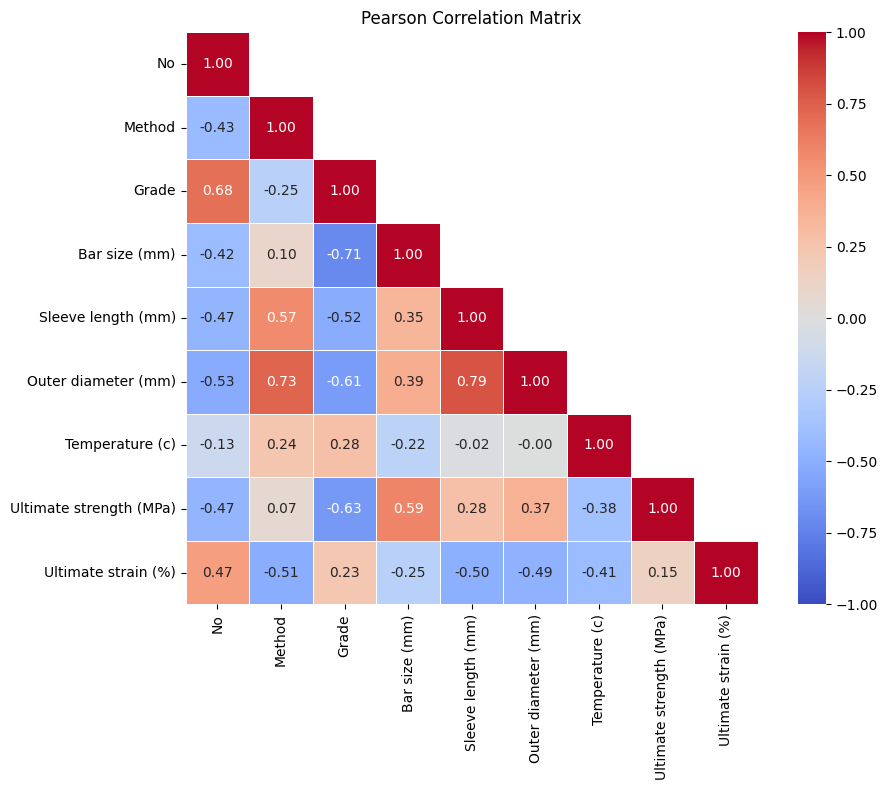

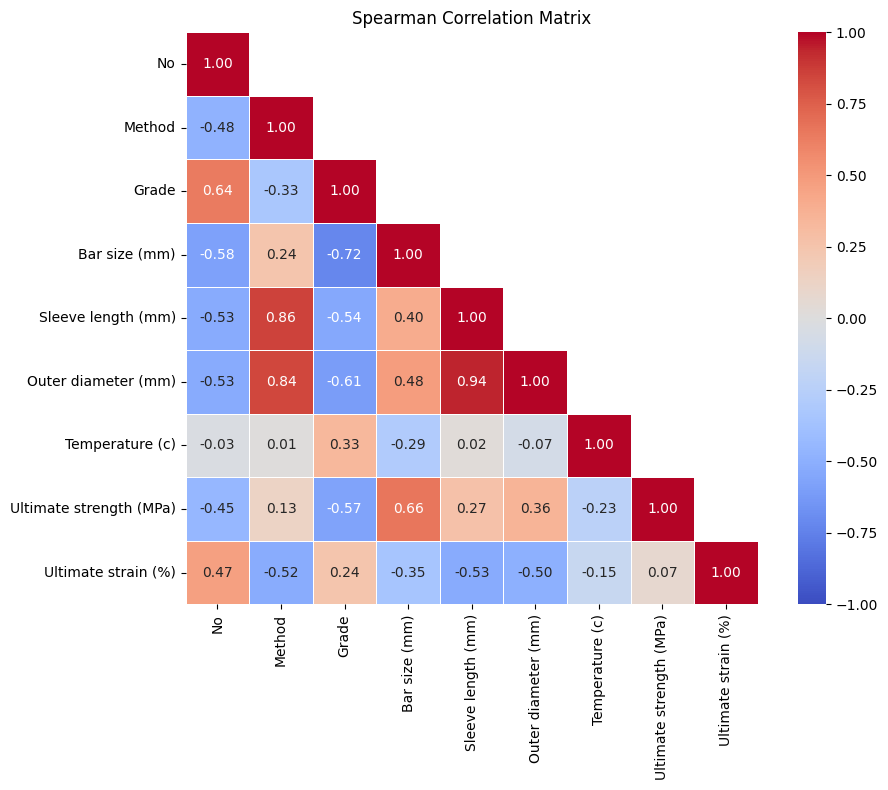

In [97]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# Select numeric columns
# ============================================================

df_num = df_clean.select_dtypes(include=np.number)

# ============================================================
# Pearson Correlation
# ============================================================

pearson_corr = df_num.corr(method='pearson')

mask = np.triu(
    np.ones_like(pearson_corr, dtype=bool),
    k=1  # keep diagonal, hide upper triangle
)

plt.figure(figsize=(10,8))

sns.heatmap(
    pearson_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

# ============================================================
# Spearman Correlation
# ============================================================

spearman_corr = df_num.corr(method='spearman')

mask = np.triu(
    np.ones_like(spearman_corr, dtype=bool),
    k=1
)

plt.figure(figsize=(10,8))

sns.heatmap(
    spearman_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

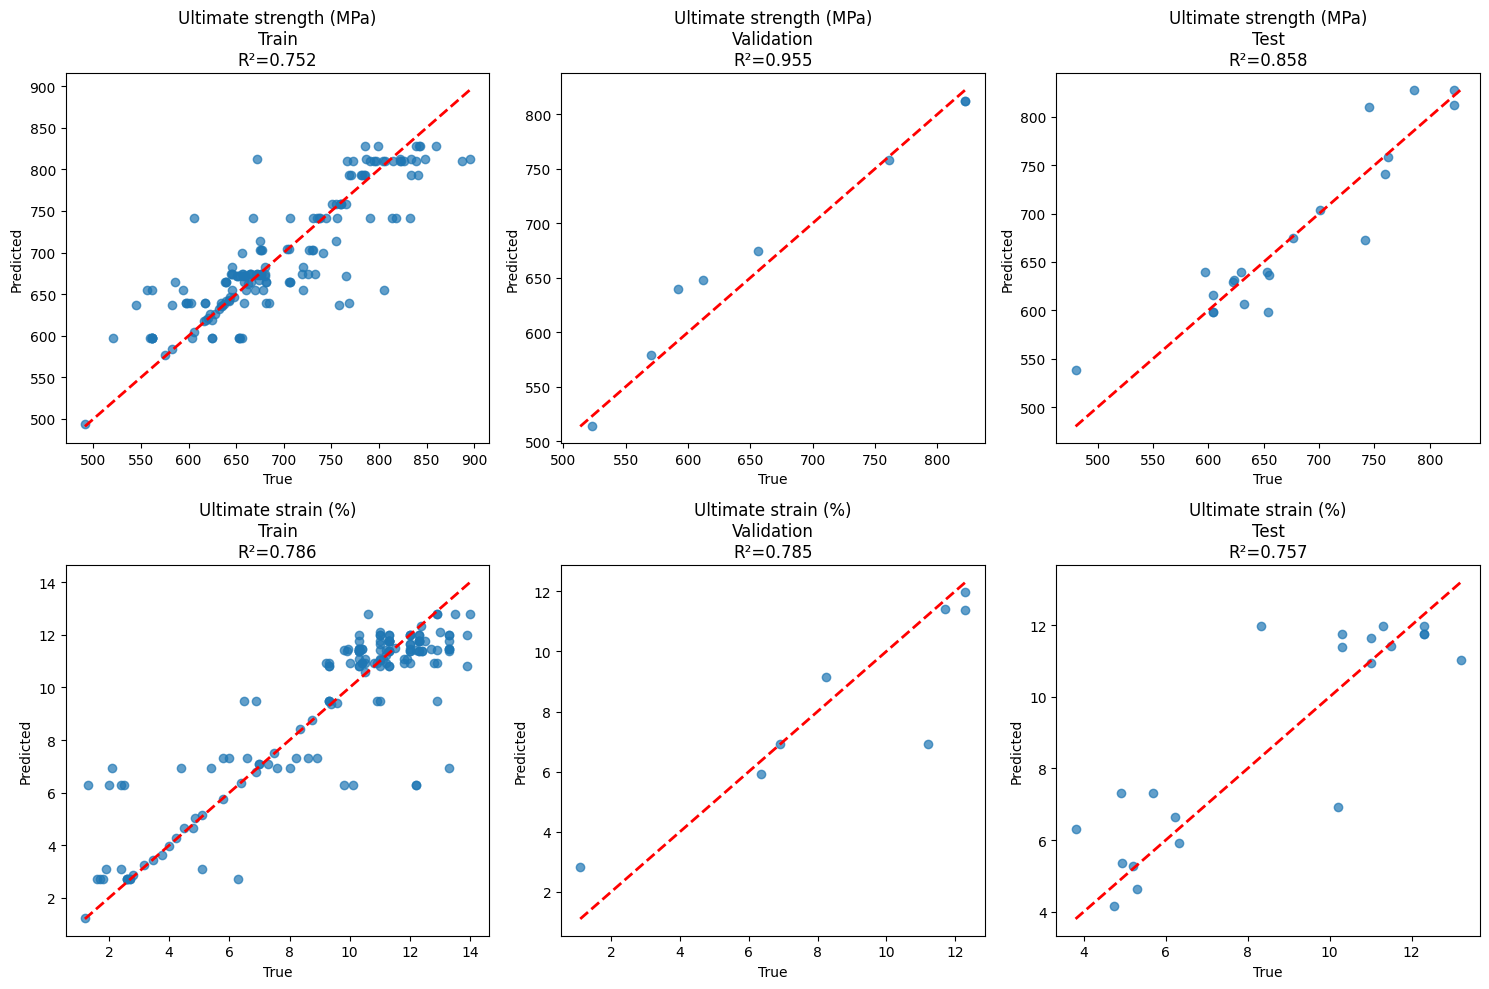


Performance Metrics
                    Target     Dataset        R2       RMSE          MSE
0  Ultimate strength (MPa)       Train  0.752260  41.446201  1717.787597
1  Ultimate strength (MPa)  Validation  0.954774  23.303784   543.066347
2  Ultimate strength (MPa)        Test  0.858054  31.854195  1014.689722
3      Ultimate strain (%)       Train  0.785755   1.593605     2.539578
4      Ultimate strain (%)  Validation  0.784598   1.703807     2.902959
5      Ultimate strain (%)        Test  0.756669   1.540107     2.371928


In [106]:
####### -----------------------------XGBoost------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# =============================================================================
# USER SETTINGS
# =============================================================================

# file_path = "/Users/hamed/Documents/Papers/6.StressStrainData/TensileDataSet.csv"

targets = [
    # "Yield stress (MPa)",
    "Ultimate strength (MPa)",
    "Ultimate strain (%)"
]

# Features
feature_cols = [
    "Method",
    # "Grade",
    "Bar size (mm)",
    "Sleeve length (mm)",
    "Outer diameter (mm)",
    "Temperature (c)"
]

# -----------------------------------------------------------------------------
# Hyperparameters for Yield Stress Model
# -----------------------------------------------------------------------------

params_fy = {
    "n_estimators": 500,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.8,         
    "colsample_bytree": 0.8,
    "random_state": 10#420
}

# -----------------------------------------------------------------------------
# Hyperparameters for Ultimate Strength Model
# -----------------------------------------------------------------------------

params_fu = {
    "n_estimators": 500,
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 40
}

# -----------------------------------------------------------------------------
# Hyperparameters for Ultimate Strain Model
# -----------------------------------------------------------------------------

params_eps = {
    "n_estimators": 500,
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 40#40
}

# =============================================================================
# LOAD DATA
# =============================================================================

# df = pd.read_csv(file_path)
df = df_clean

X = df[feature_cols]

# One-hot encoding for categorical columns
X = pd.get_dummies(X, drop_first=True)

# =============================================================================
# TRAIN / VALIDATION / TEST SPLIT
# =============================================================================

X_train, X_temp = train_test_split(
    X,
    test_size=0.15,
    random_state=42
)

X_val, X_test = train_test_split(
    X_temp,
    test_size=0.70,
    random_state=42
)

# =============================================================================
# TRAINING LOOP
# =============================================================================

param_dict = {
    "Yield stress (MPa)": params_fy,
    "Ultimate strength (MPa)": params_fu,
    "Ultimate strain (%)": params_eps
}

results = []

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 10)
)

for row_idx, target in enumerate(targets):

    y = df[target]

    y_train = y.loc[X_train.index]
    y_val = y.loc[X_val.index]
    y_test = y.loc[X_test.index]

    model = XGBRegressor(**param_dict[target])

    model.fit(
        X_train,
        y_train
    )

    # -------------------------------------------------------------------------
    # Predictions
    # -------------------------------------------------------------------------

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)

    datasets = [
        ("Train", y_train, pred_train),
        ("Validation", y_val, pred_val),
        ("Test", y_test, pred_test)
    ]

    # -------------------------------------------------------------------------
    # Metrics
    # -------------------------------------------------------------------------

    for col_idx, (name, y_true, y_pred) in enumerate(datasets):

        r2 = r2_score(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)

        results.append([
            target,
            name,
            r2,
            rmse,
            mse
        ])

        ax = axes[row_idx, col_idx]

        ax.scatter(
            y_true,
            y_pred,
            alpha=0.7
        )

        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())

        ax.plot(
            [min_val, max_val],
            [min_val, max_val],
            'r--',
            linewidth=2
        )

        ax.set_title(
            f"{target}\n{name}\nR²={r2:.3f}"
        )

        ax.set_xlabel("True")
        ax.set_ylabel("Predicted")

plt.tight_layout()
plt.show()

# =============================================================================
# PERFORMANCE TABLE
# =============================================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Target",
        "Dataset",
        "R2",
        "RMSE",
        "MSE"
    ]
)

print("\nPerformance Metrics")
print(results_df)

# =============================================================================
# SAVE RESULTS
# =============================================================================

# results_df.to_csv(
#     "XGBoost_Performance.csv",
#     index=False
# )

# print("\nSaved: XGBoost_Performance.csv")